# 05 · Capture sites and LMD wells

Deep Visual Proteomics captures **Pu.1⁺ cells** per capture site (section × compartment) by laser
microdissection and measures them by mass spectrometry. This notebook summarises how many Pu.1⁺ cells
each capture site offers, how many were selected for a well, and where they are.

Compartments: in lesion sections `core`, `rim`, and rings outside the lesion edge at 0–10 %, 10–20 %,
20–40 %, 40–60 % and >60 % of the section radius (the last two reach deep into the tissue); in control
sections the manual `GM` / `WM` regions. Manual
annotation compartments (GM, WM, vbo, manual core, unannotated) are listed for every section as well.

In [1]:
import os, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
os.chdir(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
%config InlineBackend.figure_format = 'jpeg'   # image-heavy notebooks: keep files small
plt.rcParams["figure.dpi"] = 80
from lesionseg import report as R
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 120)
RUN_DIR = "outputs/sdata"
runs = R.load_runs(RUN_DIR)
print("scenes:", [r.name for r in runs])

scenes: ['CML_1 scene 0', 'CML_2_rescan scene 0', 'CML_metal scene 0', 'CML_metal scene 1']


## Pooled over all sections

In [2]:
coh = Path(RUN_DIR) / "cohort"
pooled = pd.read_csv(coh / "capture_sites_pooled.csv")
cols = ["lesion_section", "kind", "compartment", "n_sections", "n_cells_all", "n_pu1_raw", "n_pu1_eligible", "area_pu1_eligible_um2", "n_selected", "area_selected_um2", "frac_pu1"]
pooled[pooled.compartment != "all"][cols].round(3)

,lesion_section,kind,compartment,n_sections,n_cells_all,n_pu1_raw,n_pu1_eligible,area_pu1_eligible_um2,n_selected,area_selected_um2,frac_pu1
0,False,manual annotation,manual:GM,10,27387,6168,6168,201763.515,1667,53040.993,0.225
1,False,manual annotation,manual:WM,10,14004,1945,1875,53732.405,1022,27596.455,0.139
2,False,manual annotation,manual:core,10,0,0,0,0.000,0,0.000,NaN
3,False,manual annotation,manual:unannotated,10,37480,6769,5115,151702.506,0,0.000,0.181
4,False,manual annotation,manual:vbo,10,505,50,0,0.000,0,0.000,0.099
5,False,well group,GM,10,27387,6168,6168,201763.515,1667,53040.993,0.225
6,False,well group,WM,10,14004,1945,1875,53732.405,1022,27596.455,0.139
8,True,manual annotation,manual:GM,8,0,0,0,0.000,0,0.000,NaN
9,True,manual annotation,manual:WM,8,0,0,0,0.000,0,0.000,NaN
10,True,manual annotation,manual:core,8,21907,10681,9410,275210.995,1539,42818.937,0.488


## Per section (Pu.1⁺ cells eligible for capture)

In [3]:
cap = pd.read_csv(coh / "capture_sites_by_section.csv")
wg = cap[cap.kind == "well group"]
display(wg.pivot_table(index=["sample", "scene", "section", "lesion_section"], columns="compartment", values="n_pu1_eligible", aggfunc="sum", fill_value=0).astype(int))
ma = cap[cap.kind == "manual annotation"]
display(ma.pivot_table(index=["sample", "scene", "section", "lesion_section"], columns="compartment", values="n_pu1_raw", aggfunc="sum", fill_value=0).astype(int))

compartment                                  GM   WM  core   rim  ring_0_10  ring_10_20  ring_20_40  ring_40_60  ring_60_plus
sample       scene section  lesion_section                                                                                   
CML_1        0     OS1_2_   False           159   45     0     0          0           0           0           0             0
                   OS1_2_C  False           312   64     0     0          0           0           0           0             0
                   OS1_2_L  False           209   76     0     0          0           0           0           0             0
                   P2_3_C   True              0    0   788   565        567         473         840         202             0
                   P2_3_L   True              0    0  1079   259        245         200         463         269             0
                   P2_3_T   True              0    0  1637   316        227         210         320         192             2
                   R1_3_C   False           898  257     0     0          0           0           0           0             0
                   R1_3_L   True              0    0    28    87         79         107         313         378           236
                   R1_3_T   True              0    0    13    76         54          73         247         253            96
CML_2_rescan 0     CFA_L2_C False           336   54     0     0          0           0           0           0             0
                   CFA_L2_L False           303   39     0     0          0           0           0           0             0
                   CFA_L2_T False           130   34     0     0          0           0           0           0             0
                   P3_1_C   True              0    0   701  1117        363         265         423         335            39
                   P3_1_L   False           271  258     0     0          0           0           0           0             0
                   P3_1_T   True              0    0   277   254        184         106         228         264           181
                   R1_2_C   False             0    0     0     0          0           0           0           0             0
                   R1_2_L   False           254  378     0     0          0           0           0           0             0
                   R1_2_T   True              0    0   889  1514        834         423         575          76             0
CML_metal    0     OS1_2_   False           161   31     0     0          0           0           0           0             0
                   OS1_2_C  False           602   65     0     0          0           0           0           0             0
                   OS1_2_L  False           175   23     0     0          0           0           0           0             0
                   P2_3_C   True              0    0   349   428        258         241         447         450            48
                   P2_3_L   True              0    0   647   242        232         311         409         394            21
                   P2_3_T   True              0    0  1257   280        221         149         327         141            47
                   R1_3_C   False           988  165     0     0          0           0           0           0             0
                   R1_3_L   True              0    0     0    56         74          45         185         201           547
                   R1_3_T   True              0    0     0     9         27          17         126         260           218
             1     CFA_L2_C False           284   54     0     0          0           0           0           0             0
                   CFA_L2_L False           438   23     0     0          0           0           0           0             0
                   CFA_L2_T False           135   17     0     0          0           0       

compartment                                 manual:GM  manual:WM  manual:core  manual:unannotated  manual:vbo
sample       scene section  lesion_section                                                                   
CML_1        0     OS1_2_   False                 159         47            0                  66           0
                   OS1_2_C  False                 312         65            0                 121           4
                   OS1_2_L  False                 209         79            0                 206           2
                   P2_3_C   True                    0          0          708                3571           0
                   P2_3_L   True                    0          0         1084                2038          28
                   P2_3_T   True                    0          0         1442                2297          10
                   R1_3_C   False                 898        272            0                 894          12
                   R1_3_L   True                    0          0          172                1537           0
                   R1_3_T   True                    0          0          172                 888           5
CML_2_rescan 0     CFA_L2_C False                 336         55            0                  75           2
                   CFA_L2_L False                 303         55            0                  88           0
                   CFA_L2_T False                 130         37            0                  46           1
                   P3_1_C   True                    0          0         1003                2395          11
                   P3_1_L   False                 271        259            0                 406           2
                   P3_1_T   True                    0          0          418                1259           3
                   R1_2_C   False                   0          0            0                 121           0
                   R1_2_L   False                 254        385            0                 553           8
                   R1_2_T   True                    0          0         1869                2852          14
CML_metal    0     OS1_2_   False                 161         32            0                 151           0
                   OS1_2_C  False                 602         65            0                 209           7
                   OS1_2_L  False                 175         31            0                 531           0
                   P2_3_C   True                    0          0          394                2682           0
                   P2_3_L   True                    0          0          642                2223           0
                   P2_3_T   True                    0          0          606                2379           0
                   R1_3_C   False                 988        177            0                 797           6
                   R1_3_L   True                    0          0          160                1474           0
                   R1_3_T   True                    0          0          144                 846           3
             1     CFA_L2_C False                 284         54            0                 590           1
                   CFA_L2_L False                 438         23            0                 380           2
                   CFA_L2_T False                 135         17            0                  56           3
                   P3_1_C   True                    0          0          313                3824          11
                   P3_1_L   False                 166        123            0                 419           0
                   P3_1_T   True                    0          0          467                1433           0
                   R1_2_C   False                   0          0            0                  19           0
                   R1_2_L   False       

## Per animal

In [4]:
ba = pd.read_csv(coh / "capture_sites_by_animal.csv")
ba[ba.compartment != "all"].pivot_table(index=["animal", "lesion_section"], columns="compartment", values="n_pu1_eligible", aggfunc="sum", fill_value=0).astype(int)

compartment              GM   WM  core  manual:GM  manual:WM  manual:core  manual:unannotated  manual:vbo   rim  ring_0_10  ring_10_20  ring_20_40  ring_40_60  ring_60_plus
animal lesion_section                                                                                                                                                       
CFA_L2 False           1626  221     0       1626        221            0                1141           0     0          0           0           0           0             0
OS1_2  False           1618  304     0       1618        304            0                 916           0     0          0           0           0           0             0
P2_3   True               0    0  5757          0          0         4072               11676           0  2090       1750        1584        2806        1648           118
P3_1   False            437  381     0        437        381            0                 614           0     0          0           0           0           0             0
       True               0    0  2276          0          0         2175                8445           0  3155       1203         840        1574        1072           503
R1_2   False            601  547     0        601        547            0                1598           0     0          0           0           0           0             0
       True               0    0  2865          0          0         2846                9106           0  4240       2256        1087        1420          88             0
R1_3   False           1886  422     0       1886        422            0                 846           0     0          0           0           0           0             0
       True               0    0    41          0          0          317                3489           0   228        234         242         871        1092          1097

## Wells actually formed (target 3000 µm² per well)

In [5]:
for r in runs:
    display(Markdown(f"### {r.name}"))
    w = r.wells
    display(w[w.well_group > 0][["section", "group", "well_group", "n_cells", "area_um2", "n_available", "note"]])
    short = w[(w.well_group == 0) | w.note.astype(str).str.startswith("short")]
    if len(short):
        display(Markdown(f"**Not filled / short:** {len(short)} of {len(w)} section×group combinations"))

### CML_1 scene 0

,section,group,well_group,n_cells,area_um2,n_available,note
7,OS1_2_,GM,1,115,2944.2,115,NaN
8,OS1_2_,WM,2,33,779.9,33,short: 780 µm²
16,OS1_2_C,GM,3,103,2990.9,201,NaN
17,OS1_2_C,WM,4,44,1328.9,44,short: 1329 µm²
25,OS1_2_L,GM,5,98,2994.8,130,NaN
26,OS1_2_L,WM,6,56,1328.1,56,short: 1328 µm²
27,P2_3_C,core,7,129,2984.4,530,NaN
28,P2_3_C,rim,8,120,2987.4,397,NaN
29,P2_3_C,ring_0_10,9,116,2987.4,393,NaN
30,P2_3_C,ring_10_20,10,108,2978.7,306,NaN


**Not filled / short:** 53 of 81 section×group combinations

### CML_2_rescan scene 0

,section,group,well_group,n_cells,area_um2,n_available,note
7,CFA_L2_C,GM,1,89,2990.7,213,NaN
8,CFA_L2_C,WM,2,38,1131.0,38,short: 1131 µm²
16,CFA_L2_L,GM,3,86,2998.2,193,NaN
17,CFA_L2_L,WM,4,27,760.0,27,short: 760 µm²
25,CFA_L2_T,GM,5,84,2297.8,84,short: 2298 µm²
26,CFA_L2_T,WM,6,22,633.9,22,short: 634 µm²
27,P3_1_C,core,7,93,2968.3,487,NaN
28,P3_1_C,rim,8,98,2995.6,750,NaN
29,P3_1_C,ring_0_10,9,98,2974.1,251,NaN
30,P3_1_C,ring_10_20,10,89,2982.1,178,NaN


...

,section,group,well_group,n_cells,area_um2,n_available,note
7,OS1_2_,GM,1,82,2991.0,105,NaN
8,OS1_2_,WM,2,22,781.6,22,short: 782 µm²
16,OS1_2_C,GM,3,91,2973.2,408,NaN
17,OS1_2_C,WM,4,40,1063.5,40,short: 1064 µm²
25,OS1_2_L,GM,5,78,2979.2,110,NaN
26,OS1_2_L,WM,6,18,561.3,18,short: 561 µm²
27,P2_3_C,core,7,95,2979.9,242,NaN
28,P2_3_C,rim,8,100,2982.8,301,NaN
29,P2_3_C,ring_0_10,9,111,2996.4,177,NaN
30,P2_3_C,ring_10_20,10,98,2976.0,163,NaN


**Not filled / short:** 55 of 81 section×group combinations

### CML_metal scene 1

,section,group,well_group,n_cells,area_um2,n_available,note
7,CFA_L2_C,GM,1,81,2980.1,199,NaN
8,CFA_L2_C,WM,2,34,1112.2,34,short: 1112 µm²
16,CFA_L2_L,GM,3,77,2966.7,284,NaN
17,CFA_L2_L,WM,4,12,412.4,12,short: 412 µm²
25,CFA_L2_T,GM,5,93,2981.5,93,NaN
26,CFA_L2_T,WM,6,12,362.6,12,short: 363 µm²
27,P3_1_C,core,7,114,2994.6,690,NaN
28,P3_1_C,rim,8,113,2977.9,957,NaN
29,P3_1_C,ring_0_10,9,103,2982.5,307,NaN
30,P3_1_C,ring_10_20,10,97,2985.4,235,NaN


**Not filled / short:** 57 of 81 section×group combinations

## Where the selected cells are

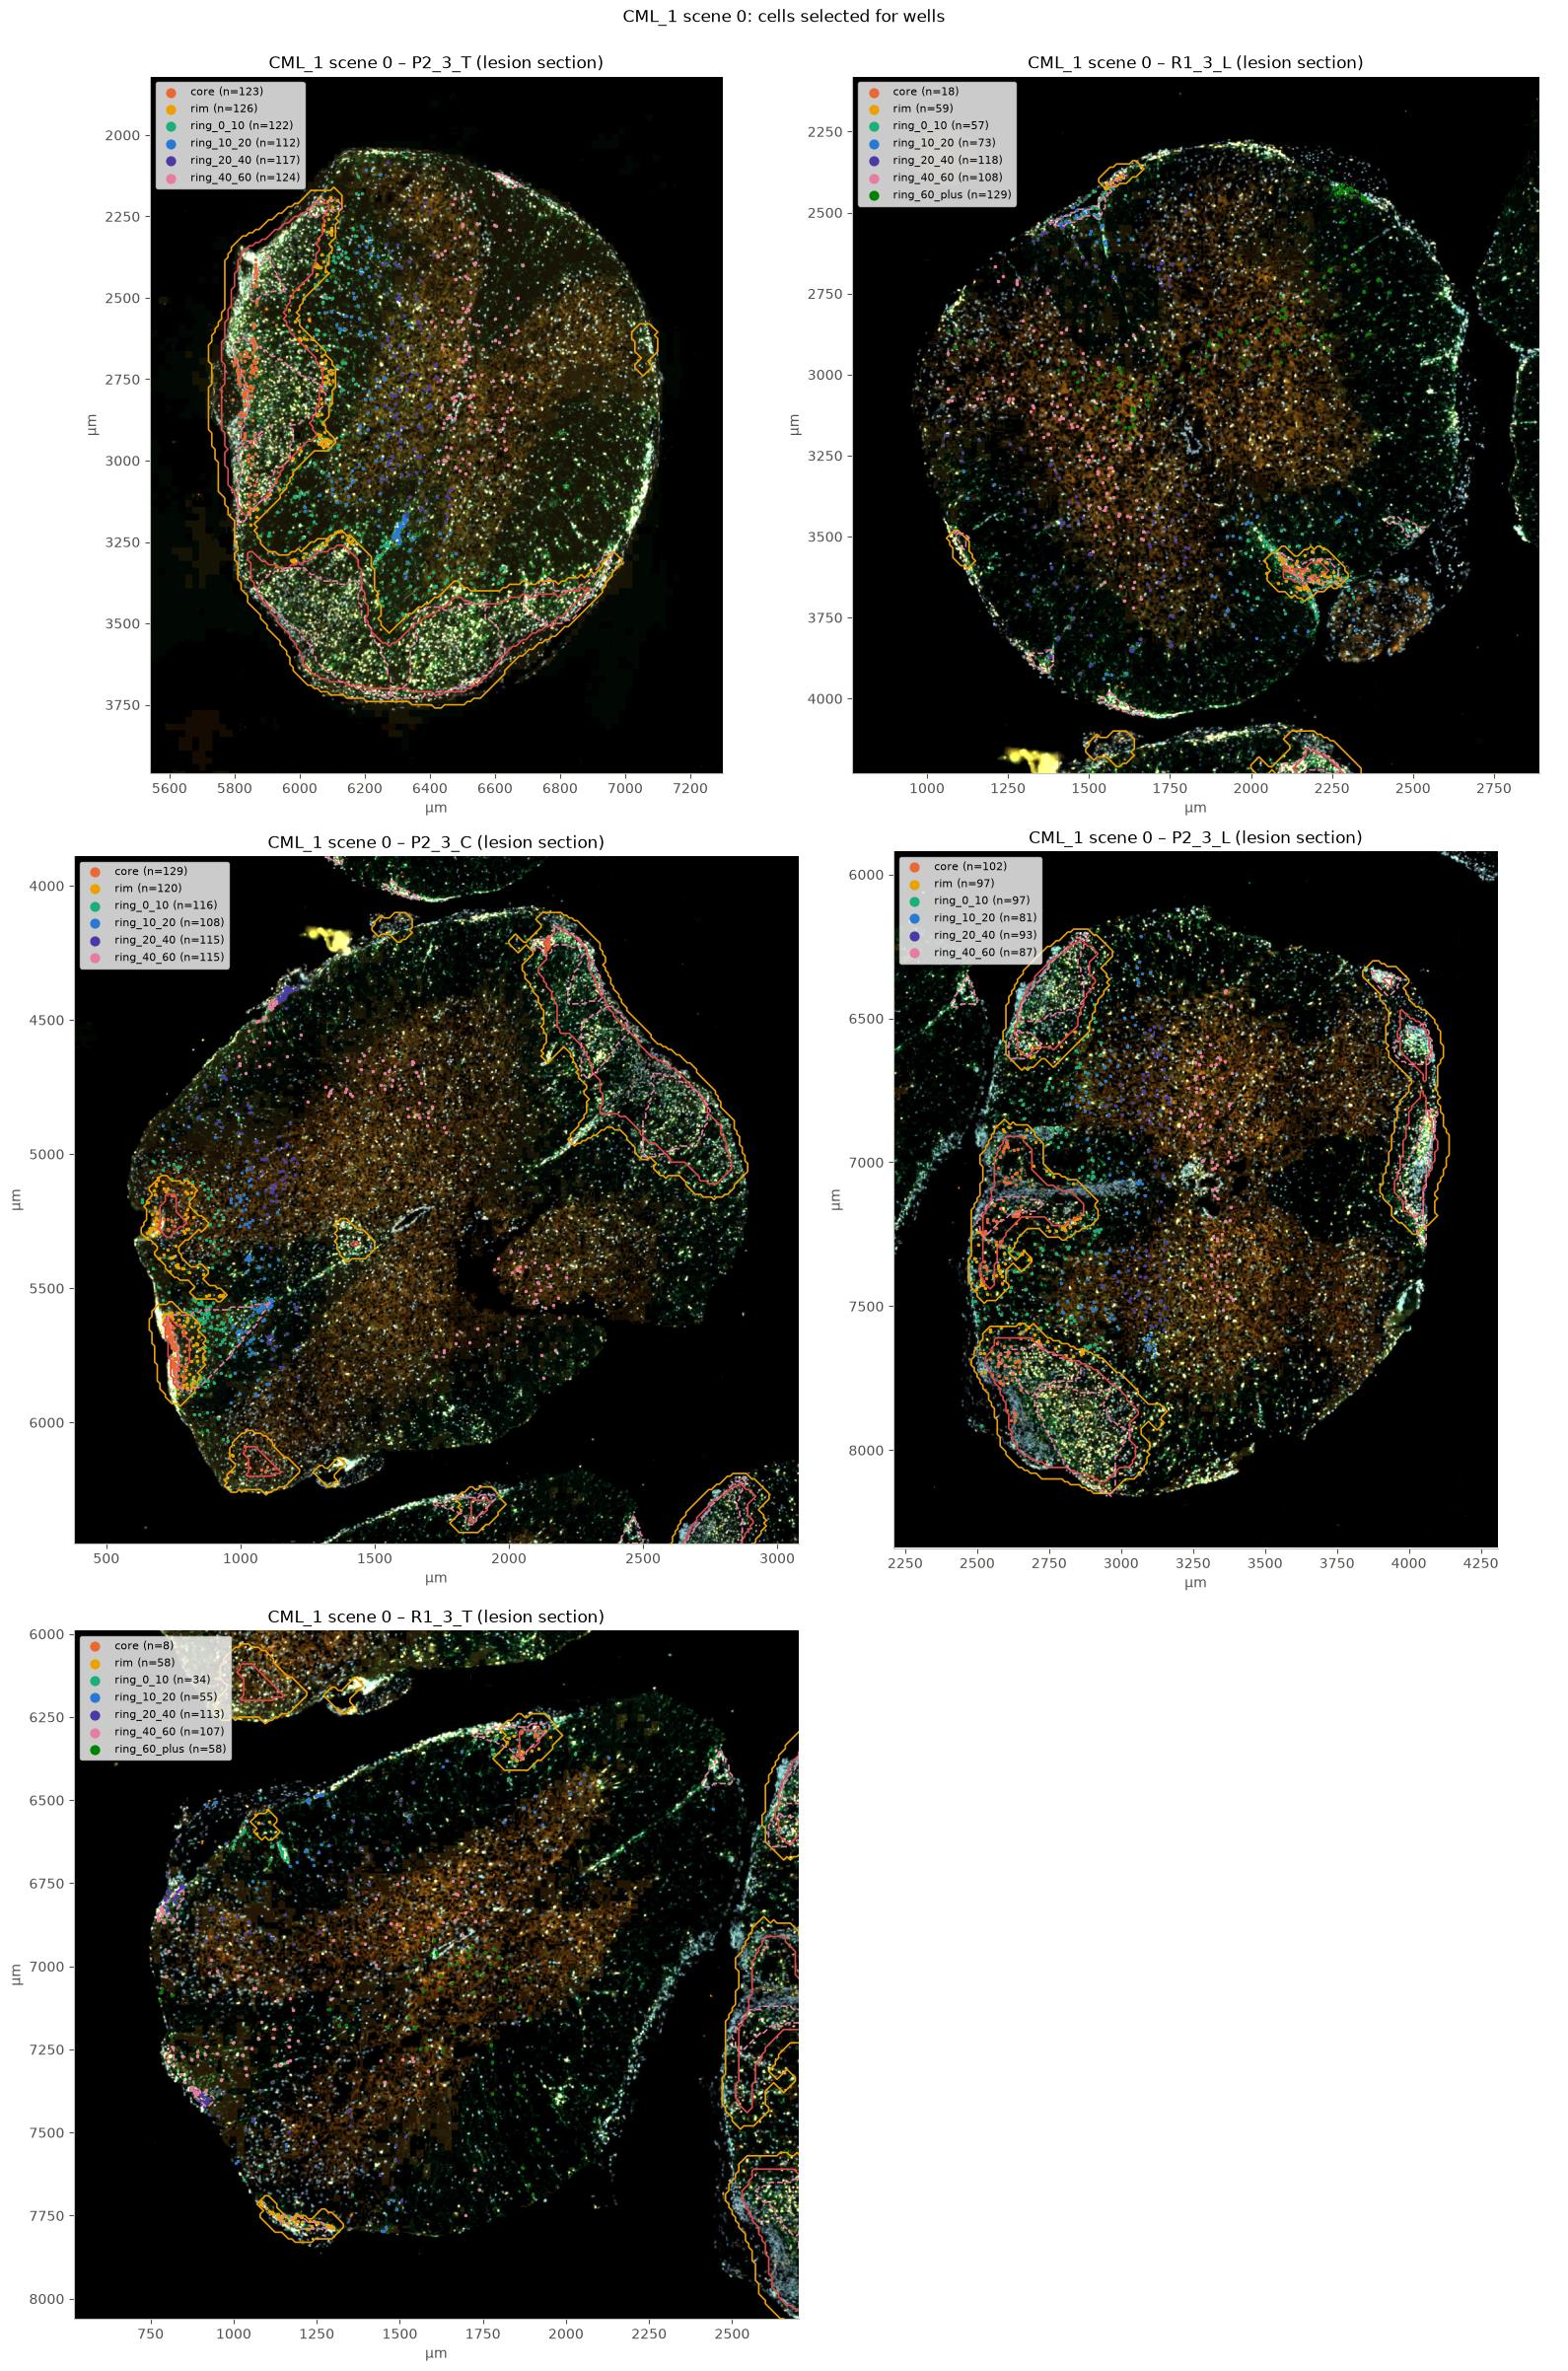

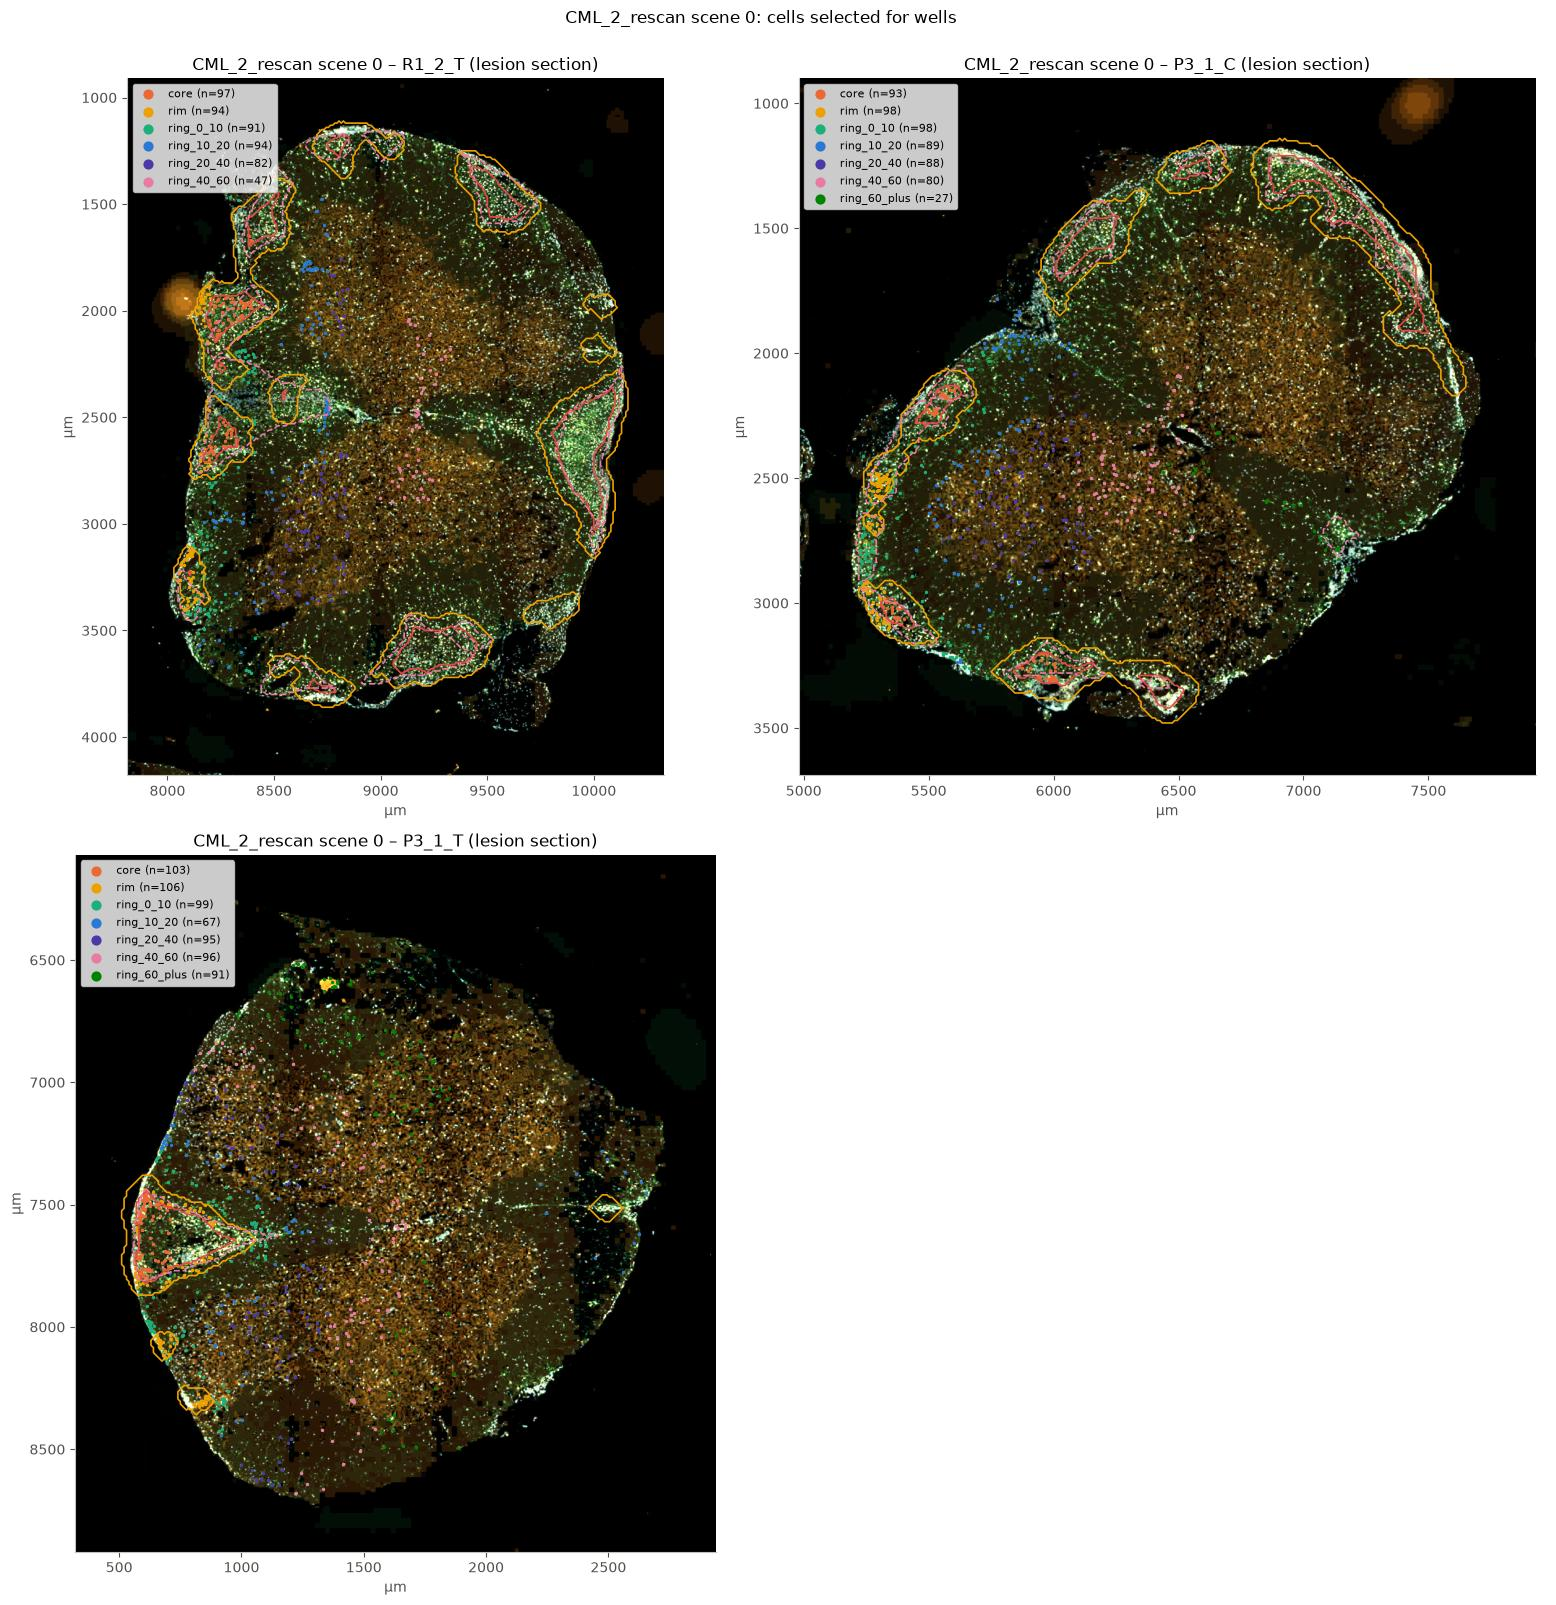

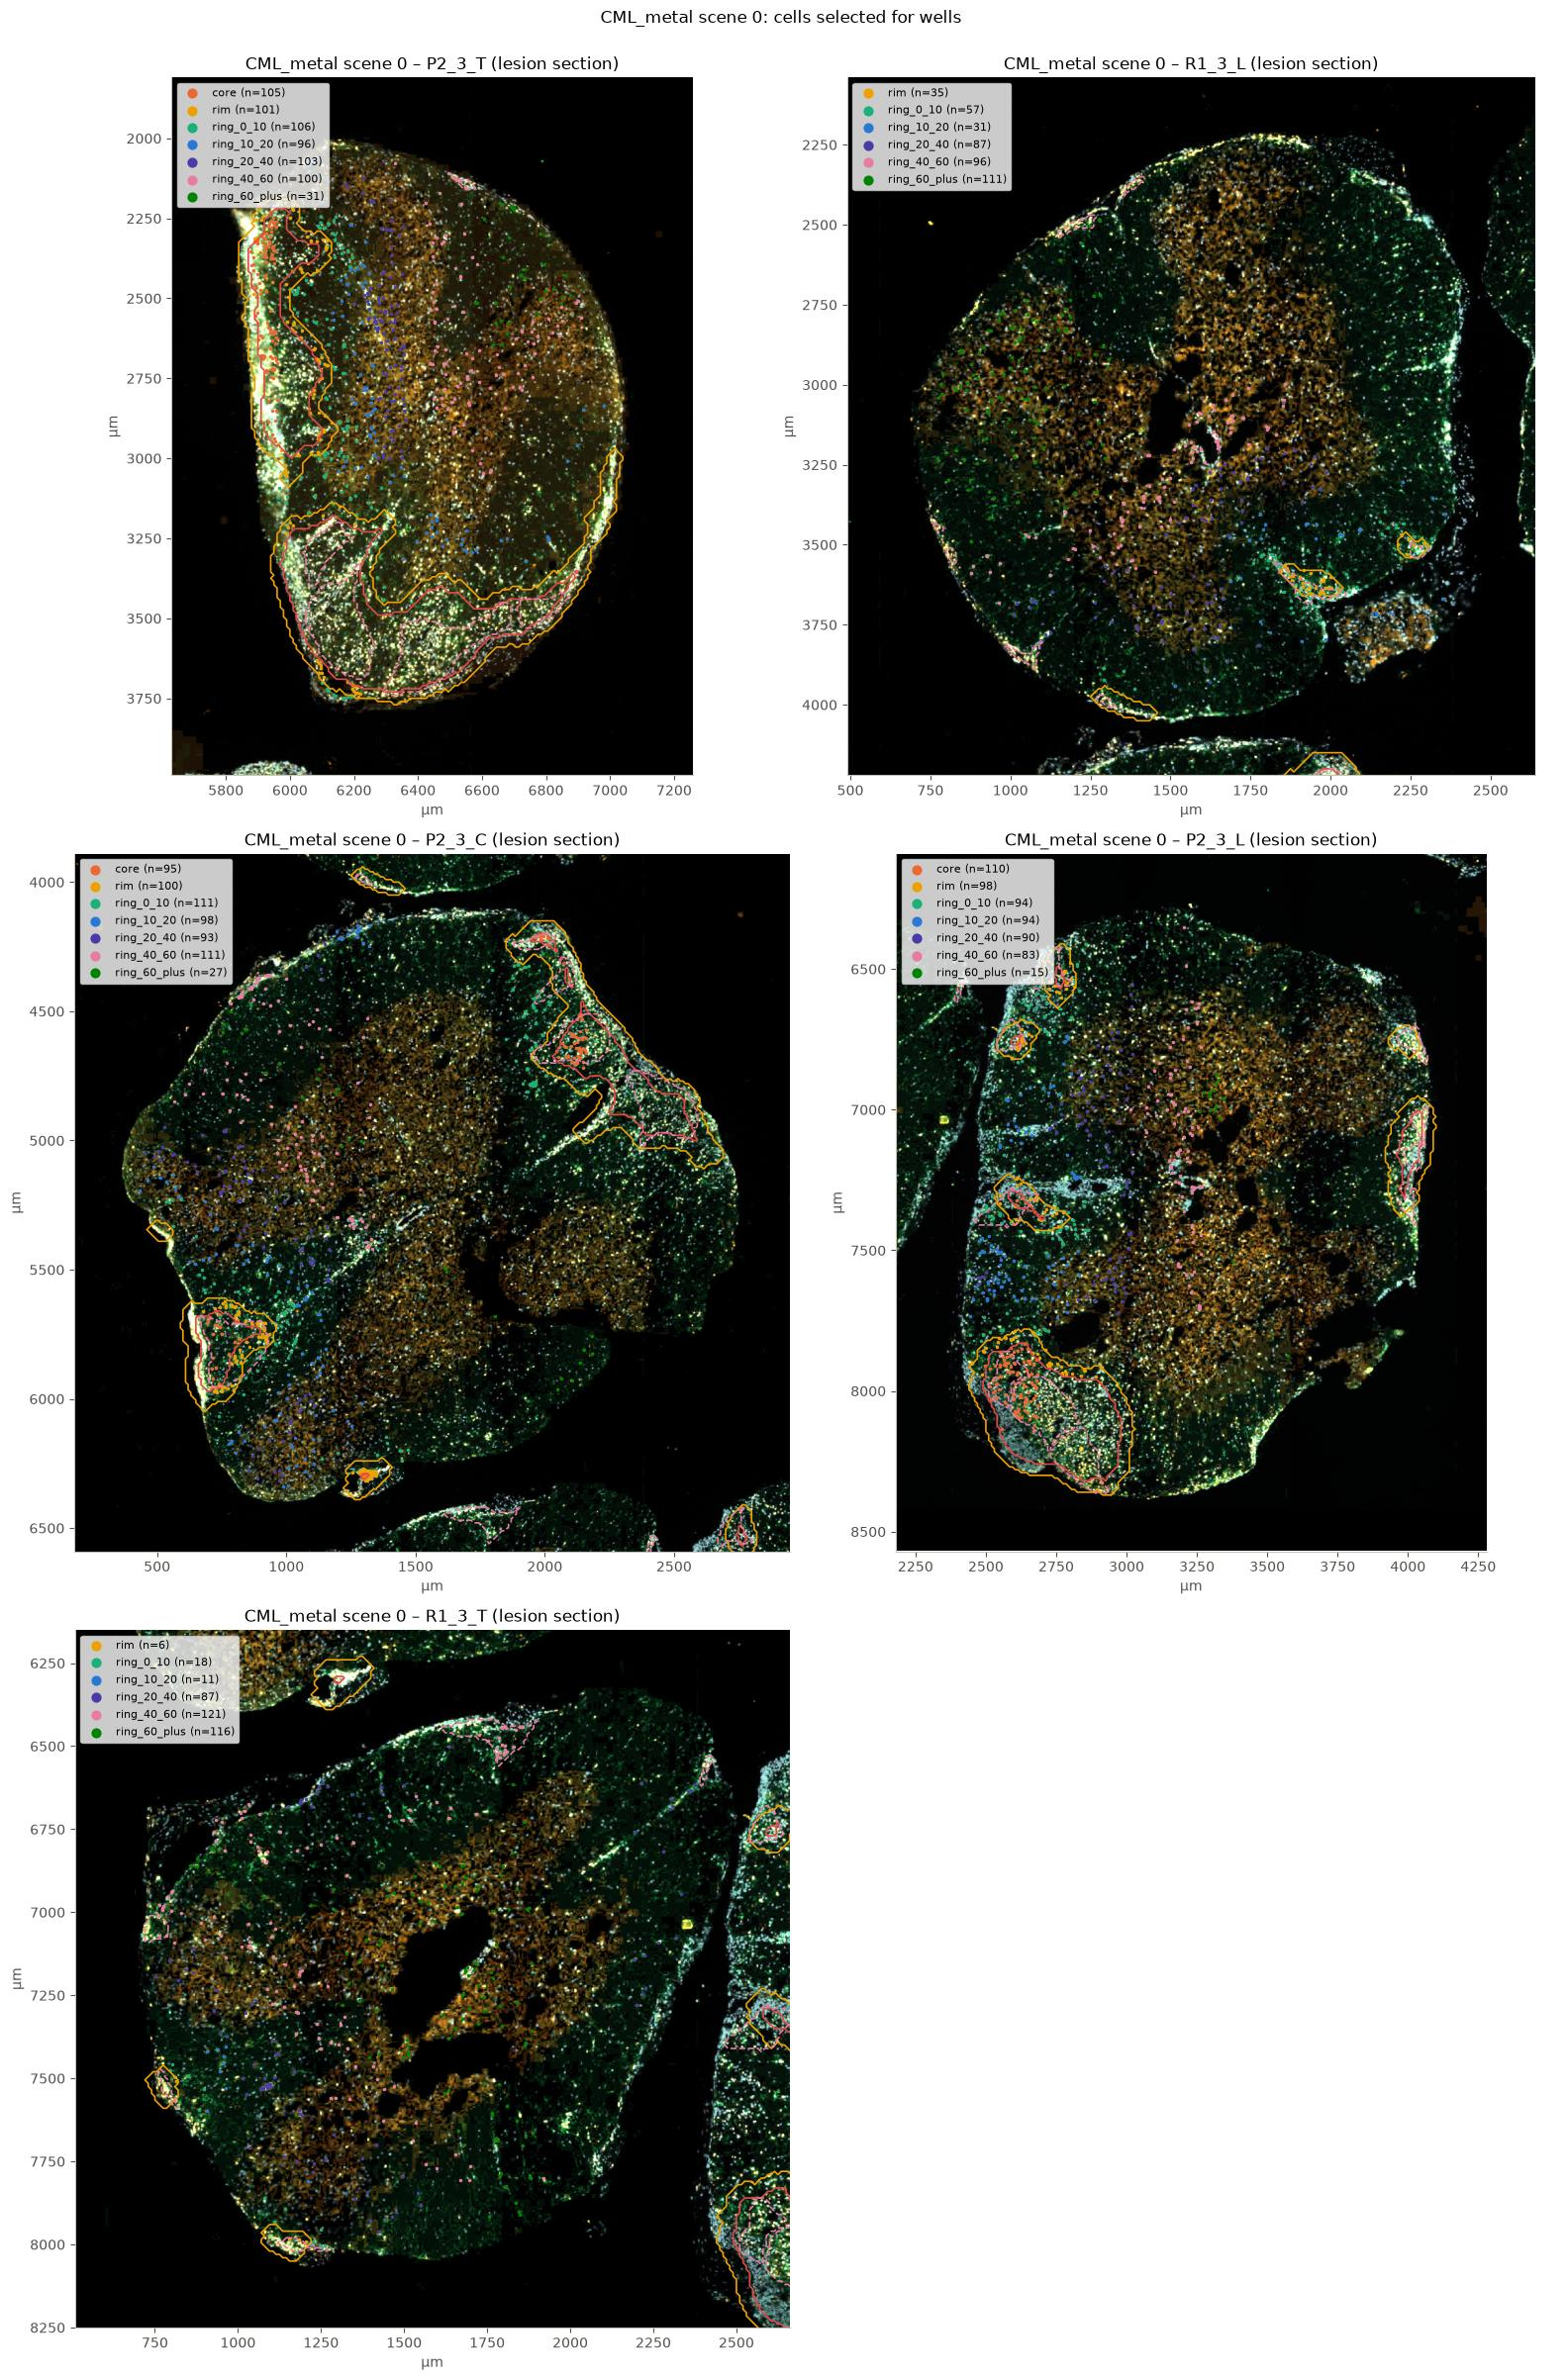

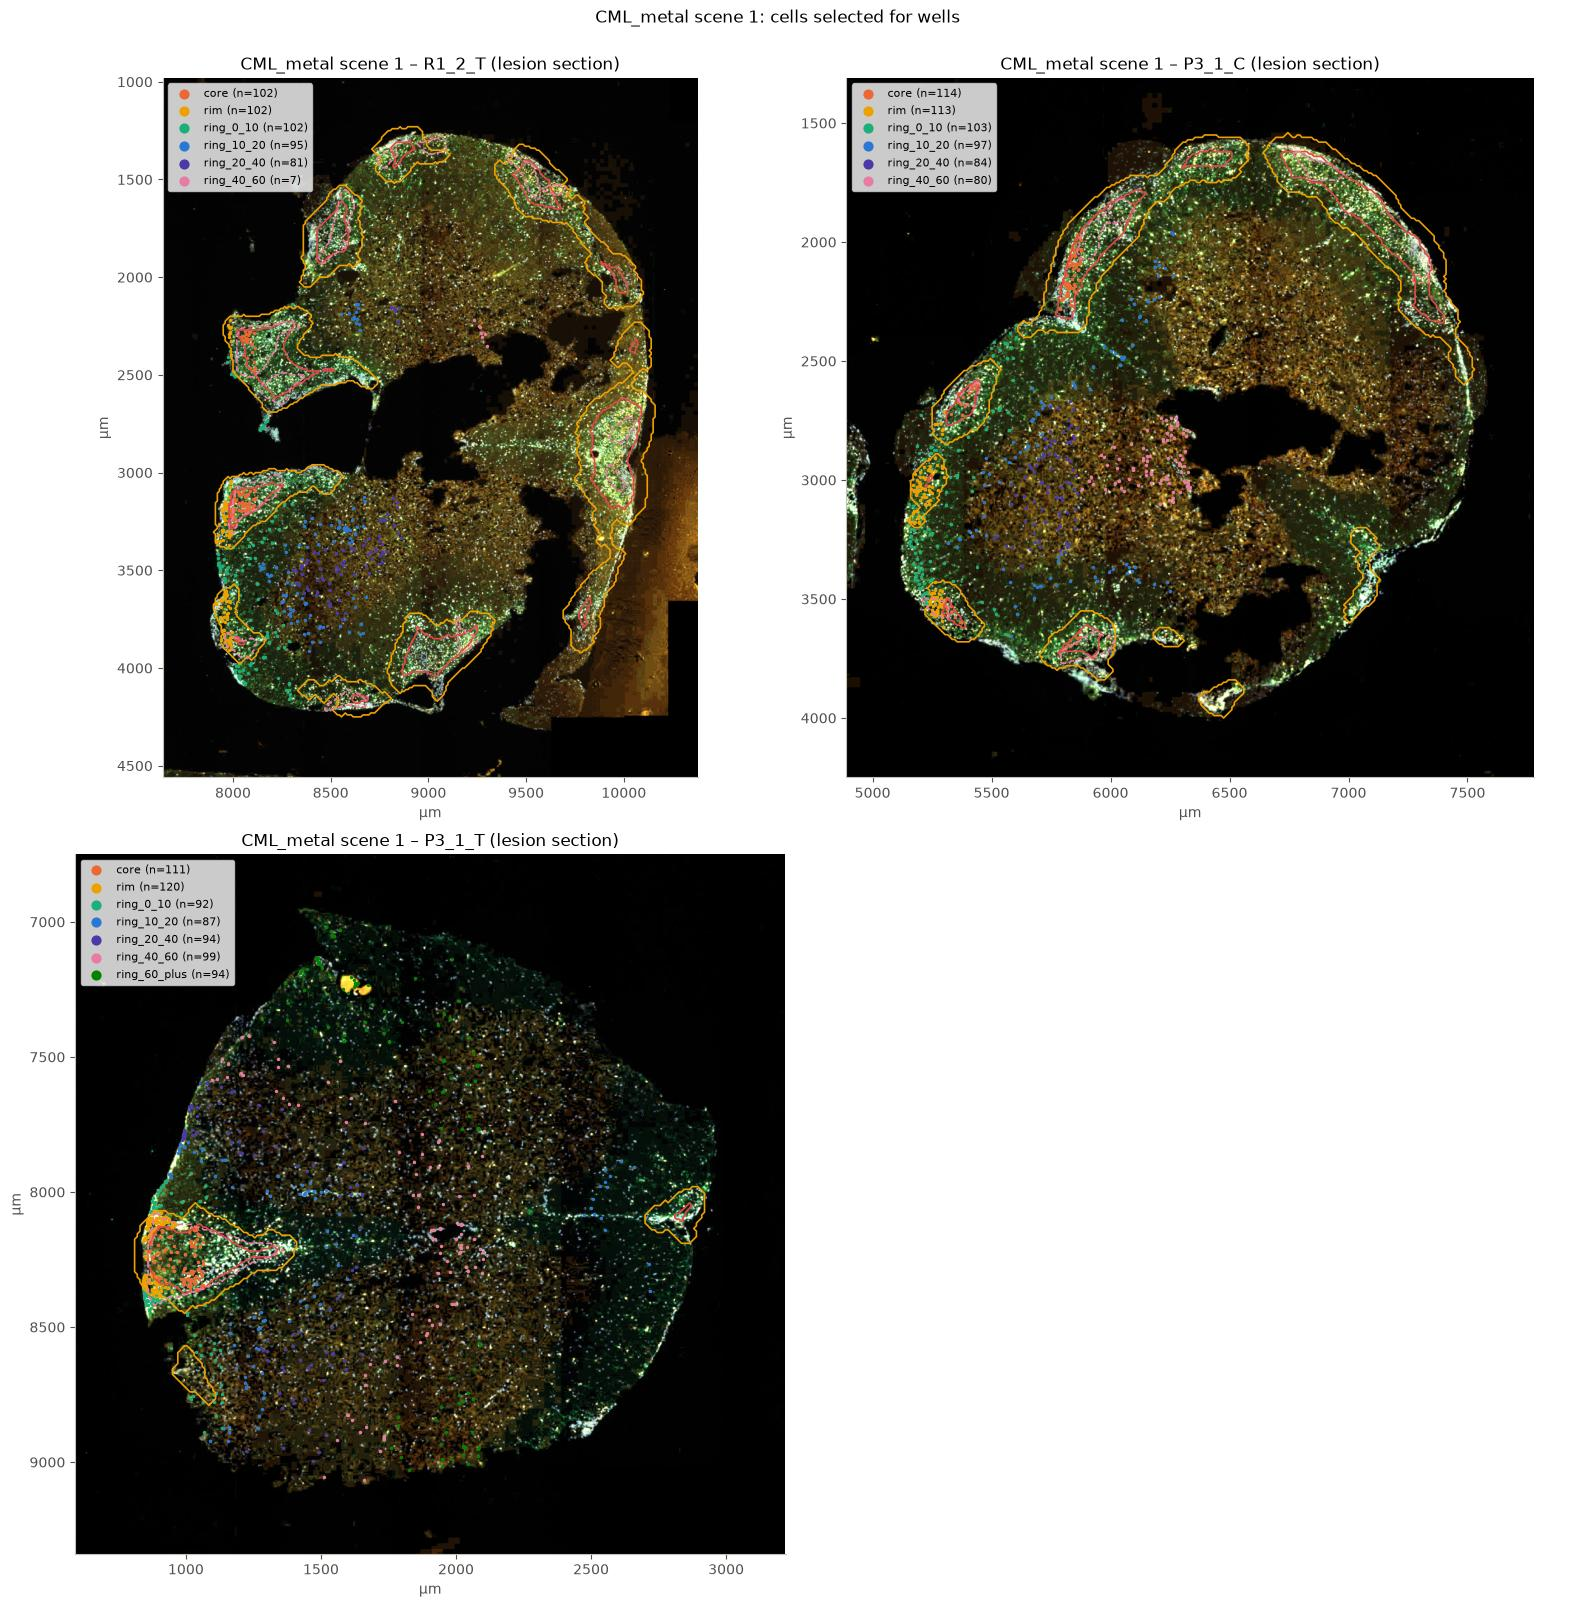

In [6]:
for r in runs:
    les = r.sections[r.sections.is_lesion_section]
    n = len(les)
    if n == 0:
        continue
    fig, axes = plt.subplots(int(np.ceil(n / 2)), 2, figsize=(16, 8 * int(np.ceil(n / 2))), squeeze=False)
    for ax, sid in zip(axes.ravel(), les.section_id):
        R.plot_section(r, int(sid), ax=ax, scale=0.2, show_cells=False)
        c = r.cells[(r.cells.section_id == sid) & (r.cells.well_group > 0)]
        for grp, s in c.groupby(c.well_name.str.split("|").str[1]):
            ax.scatter(s.x_um, s.y_um, s=6, c=R.GROUP_COLORS.get(grp, "#ffffff"), linewidths=0, label=f"{grp} (n={len(s)})")
        ax.legend(markerscale=3, fontsize=8, loc="upper left")
    for ax in axes.ravel()[n:]:
        ax.axis("off")
    fig.suptitle(f"{r.name}: cells selected for wells", y=1.0)
    plt.tight_layout(); plt.show()

## Overlap with the collaborator's own selection (`cells_selected` in the table)

In [7]:
for r in runs:
    c = r.cells
    theirs = c["cells_selected"].notna() & ~c["cells_selected"].astype(str).isin(["None", "nan"])
    display(Markdown(f"### {r.name}: collaborator selected {int(theirs.sum())} cells, this run selected {int((c.well_group > 0).sum())}; overlap {int((theirs & (c.well_group > 0)).sum())}"))
    display(pd.crosstab(c.loc[theirs, "manual_annotation"].fillna("ring (no manual label)"), c.loc[theirs, "zone"]))

### CML_1 scene 0: collaborator selected 2666 cells, this run selected 3671; overlap 1932

zone,distal,peri,rim,core
manual_annotation,,,,
GM,383,0,0,0
WM,274,0,0,0
core,87,93,138,261
ring (no manual label),524,434,260,212


### CML_2_rescan scene 0: collaborator selected 1842 cells, this run selected 2497; overlap 1425

zone,distal,peri,rim,core
manual_annotation,,,,
GM,444,0,0,0
WM,328,0,0,0
core,0,44,146,119
ring (no manual label),240,365,153,3


### CML_metal scene 0: collaborator selected 274 cells, this run selected 3186; overlap 199

zone,distal,peri,rim
manual_annotation,,,
WM,80,0,0
core,20,0,0
ring (no manual label),109,55,10


### CML_metal scene 1: collaborator selected 136 cells, this run selected 2463; overlap 84

zone,distal,peri,rim,core
manual_annotation,,,,
GM,14,0,0,0
WM,53,0,0,0
ring (no manual label),1,39,28,1


## LMD export

`lesionseg export-lmd` writes one Leica XML per scene with one well per `well_name`. It needs the
three calibration-mark coordinates in scene pixels; the demo below uses placeholders so the file
structure can be inspected.

In [8]:
from lesionseg.export import export_lmd
r = runs[0]
calib = np.array([[500, 500], [r.log["scene_shape_px"][1] - 500, 500], [500, r.log["scene_shape_px"][0] - 500]], float)  # PLACEHOLDER
out = r.dir / "demo_lmd.xml"
counts = export_lmd(r.cells, out, calibration_points_px=calib, group_col="well_name", pixel_size_um=r.px, dilate_um=1.0)
print(f"{out}: {sum(counts.values())} shapes in {len(counts)} wells")
print(out.read_text()[:600])

[50000. 50000.]
[2361700.   50000.]
[  50000. 2728100.]
outputs/sdata/CML_1/scene0/demo_lmd.xml: 3671 shapes in 40 wells
<?xml version='1.0' encoding='UTF-8'?>
<ImageData>
  <GlobalCoordinates>1</GlobalCoordinates>
  <X_CalibrationPoint_1>50000</X_CalibrationPoint_1>
  <Y_CalibrationPoint_1>50000</Y_CalibrationPoint_1>
  <X_CalibrationPoint_2>2361700</X_CalibrationPoint_2>
  <Y_CalibrationPoint_2>50000</Y_CalibrationPoint_2>
  <X_CalibrationPoint_3>50000</X_CalibrationPoint_3>
  <Y_CalibrationPoint_3>2728100</Y_CalibrationPoint_3>
  <ShapeCount>3671</ShapeCount>
  <Shape_1>
    <PointCount>209</PointCount>
    <CapID>C2</CapID>
    <X_1>1178042</X_1>
    <Y_1>482573</Y_1>
    <X_2>1178032</X_2>
    <Y_2>482582</
